In [16]:
# Assignment 02 - Q1

import cv2 as cv
import numpy as np

# Read image in grayscale
img = cv.imread(r"C:\Users\Dilshan\Pictures\Screenshots\Screenshot 2026-03-19 095619.png", cv.IMREAD_GRAYSCALE)

# Apply Canny Edge Detection
edges = cv.Canny(img, 550, 690)

# Resize images (width, height)
img_resized = cv.resize(img, (500, 400))
edges_resized = cv.resize(edges, (500, 400))

cv.imshow('Original Image (Resized)', img_resized)
cv.imshow('Canny Edge Image (Resized)', edges_resized)

cv.waitKey(0)
cv.destroyAllWindows()

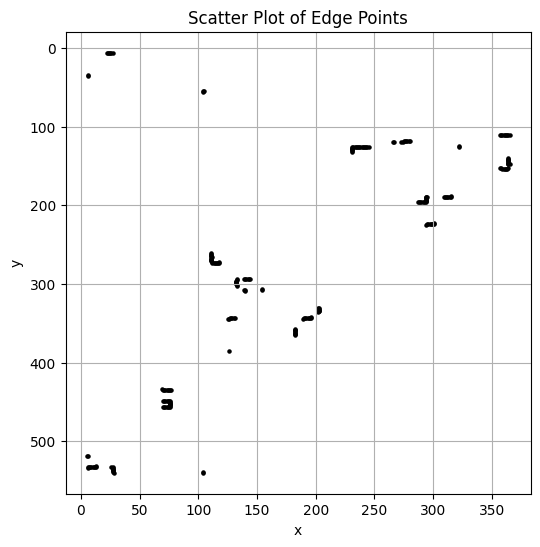

In [14]:
#Q2
import matplotlib.pyplot as plt

# Extract coordinates of edge points
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='black')
plt.title('Scatter Plot of Edge Points')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()   # Makes image-like coordinate view
plt.grid(True)
plt.show()

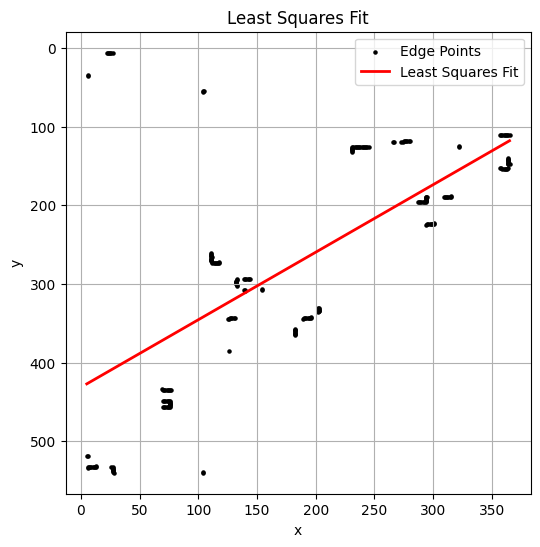

Least Squares slope (m) = -0.85868501872158
Least Squares intercept (c) = 431.3432187158599


In [8]:
#Q3
m_lsf, c_lsf = np.polyfit(x, y, 1)

# Generate fitted line
x_line = np.linspace(np.min(x), np.max(x), 500)
y_line_lsf = m_lsf * x_line + c_lsf

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='black', label='Edge Points')
plt.plot(x_line, y_line_lsf, 'r', linewidth=2, label='Least Squares Fit')
plt.title('Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

print("Least Squares slope (m) =", m_lsf)
print("Least Squares intercept (c) =", c_lsf)

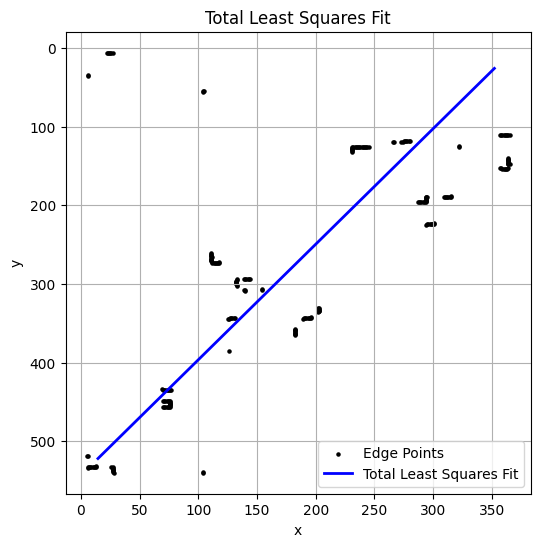

In [17]:
#Q6
points = np.column_stack((x, y))
mean = np.mean(points, axis=0)
centered = points - mean

# Covariance matrix
cov = np.cov(centered.T)

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov)

# Direction vector corresponds to largest eigenvalue
direction = eigenvectors[:, np.argmax(eigenvalues)]

dx, dy = direction[0], direction[1]

# Create TLS line
t = np.linspace(-300, 300, 500)
x_tls = mean[0] + t * dx
y_tls = mean[1] + t * dy

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='black', label='Edge Points')
plt.plot(x_tls, y_tls, 'b', linewidth=2, label='Total Least Squares Fit')
plt.title('Total Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Q7
theta_tls = np.degrees(np.arctan2(dy, dx))
print("Estimated crop field angle using Total Least Squares Fit =", theta_tls, "degrees")

Estimated crop field angle using Total Least Squares Fit = -55.760438453793505 degrees


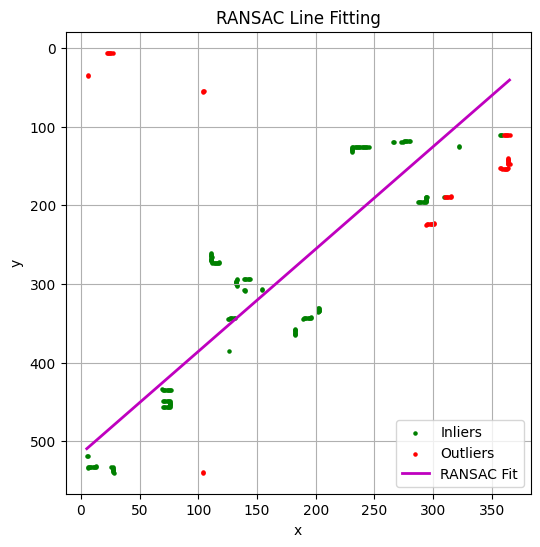

RANSAC slope = -1.3019575540312527
RANSAC intercept = 515.9430739530262


In [21]:
#Q10
from sklearn.linear_model import RANSACRegressor, LinearRegression
X = x.reshape(-1, 1)
Y = y

# RANSAC model
ransac = RANSACRegressor(estimator=LinearRegression(), random_state=0)
ransac.fit(X, Y)

# Predicted line
y_ransac = ransac.predict(x_line.reshape(-1, 1))

# Inlier mask
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x[inlier_mask], y[inlier_mask], s=5, c='green', label='Inliers')
plt.scatter(x[outlier_mask], y[outlier_mask], s=5, c='red', label='Outliers')
plt.plot(x_line, y_ransac, 'm', linewidth=2, label='RANSAC Fit')
plt.title('RANSAC Line Fitting')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

# Extract slope and intercept
m_ransac = ransac.estimator_.coef_[0]
c_ransac = ransac.estimator_.intercept_

print("RANSAC slope =", m_ransac)
print("RANSAC intercept =", c_ransac)

In [22]:
theta_ransac = np.degrees(np.arctan(m_ransac))
print("Estimated crop field angle using RANSAC =", theta_ransac, "degrees")

Estimated crop field angle using RANSAC = -52.47306356908684 degrees
